In [17]:
import PcmPy as pcm
import numpy as np
import matplotlib.pyplot as plt
import globals as gl
import os
import mat73
import warnings
from lfp import make_freq_masks
from vis import plot_dissimilarities
from scipy.signal import resample

warnings.filterwarnings("ignore")

plt.style.use('default')

In [18]:
monkey = 'Malfoy'
path_lfp = '/cifs/pruszynski/Marco/SensoriMotorPrediction/LFPs/' #+ monkey + '/'
path_spk = '/cifs/pruszynski/Marco/SensoriMotorPrediction/spikes/' #+ monkey + '/'
cfg = mat73.loadmat(os.path.join(path_lfp,'Malfoy/cfg.PMd-19.mat'))['cfg']
foi = cfg['foi']
freq_masks = make_freq_masks(cfg)

cuePre = 0
cueIdx = 20
cuePost = 84
pertPre = cuePost + 1
pertIdx = pertPre + 30
pertPost = pertPre + 70

t_cue = np.linspace(0, cuePost - 1, cuePost)
t_pert = np.linspace(pertPre, pertPost - 1, pertPost - pertPre - 1)

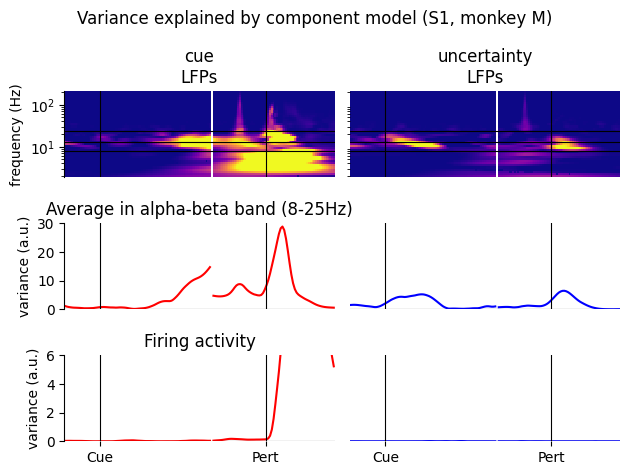

In [22]:
roi = 'S1'
epoch = 'plan'
rec = [26, 27, 28] #recordings[roi]
freq = freq_masks['alpha-beta']
var_expl_lfp, var_expl_spk = [], []
for r in rec:
    theta_lfp = np.load(os.path.join(path_lfp, monkey, f'theta_in.lfp.component.{monkey}.{roi}.{epoch}-{r}.npy'))
    theta_spk = np.load(os.path.join(path_spk, monkey, f'theta_in.spike.component.{monkey}.{roi}.aligned.{epoch}-{r}.npy'))
    var_expl_lfp.append(np.exp(theta_lfp))
    var_expl_spk.append(np.exp(theta_spk))
var_expl_lfp = np.array(var_expl_lfp)
var_expl_spk = np.array(var_expl_spk)

fig, axs = plt.subplots(3, 2, sharey='row', sharex=True)

vmin, vmax = 0, 12
color = ['red', 'blue']
label = ['cue', 'uncertainty']
for i in range(2):
    axs[0, i].pcolormesh(t_cue, foi, var_expl_lfp[:, :, :cuePost, i].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, i].pcolormesh(t_pert, foi, var_expl_lfp[:, :, pertPre:pertPost, i].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, i].set_yscale('log')
    axs[0, i].axhline(8, color='k', lw='.8')
    axs[0, i].axhline(13, color='k', lw='.8')
    axs[0, i].axhline(24, color='k', lw='.8')
    axs[1, i].plot(t_cue, var_expl_lfp[:, freq, :cuePost, i].mean(axis=(0, 1)), color=color[i])
    axs[1, i].plot(t_pert, var_expl_lfp[:, freq, pertPre:, i].mean(axis=(0, 1)), color=color[i])
    axs[2, i].plot(t_cue, var_expl_spk[:, :cuePost, i].mean(axis=0), color=color[i])
    axs[2, i].plot(t_pert, var_expl_spk[:, pertPre:, i].mean(axis=0), color=color[i])
    axs[1, i].axhline(0, color='k', lw='.8')
    axs[2, i].axhline(0, color='k', lw='.8')
    axs[1, i].set_ylim(0, 30)
    axs[2, i].set_ylim(0, 6)
    for j in range(3):
        axs[j, i].axvline(cueIdx, color='k', lw='.8')
        axs[j, i].axvline(pertIdx, color='k', lw='.8')
        if j < 2:
            axs[j, i].tick_params(bottom=False, labelbottom=False)
        else:
            axs[j, i].set_xticks([cueIdx, pertIdx])
            axs[j, i].set_xticklabels(['Cue', 'Pert'])
        if i==0:
            axs[j, i].spines[['top', 'right', 'bottom']].set_visible(False)
        else:
            axs[j, i].spines[['top', 'right', 'bottom', 'left']].set_visible(False)
            axs[j, i].tick_params(left=False)

axs[0, 0].set_title('cue\nLFPs')
axs[0, 1].set_title('uncertainty\nLFPs')
axs[0, 0].set_ylabel('frequency (Hz)')
axs[1, 0].set_ylabel('variance (a.u.)')
axs[1, 0].set_title('Average in alpha-beta band (8-25Hz)')
axs[2, 0].set_ylabel('variance (a.u.)')
axs[2, 0].set_title('Firing activity')

fig.suptitle(f'Variance explained by component model ({roi}, monkey {monkey[0]})')
fig.tight_layout()

plt.show()

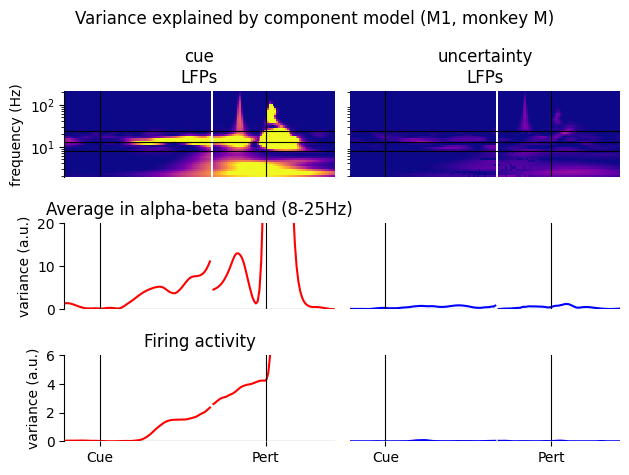

In [26]:
roi = 'M1'
epoch = 'plan'
rec = [25, 27, 28] #recordings[roi]
freq = freq_masks['alpha-beta']
var_expl_lfp, var_expl_spk = [], []
for r in rec:
    theta_lfp = np.load(os.path.join(path_lfp, monkey, f'theta_in.lfp.component.{monkey}.{roi}.{epoch}-{r}.npy'))
    theta_spk = np.load(os.path.join(path_spk, monkey, f'theta_in.spike.component.{monkey}.{roi}.aligned.{epoch}-{r}.npy'))
    var_expl_lfp.append(np.exp(theta_lfp))
    var_expl_spk.append(np.exp(theta_spk))
var_expl_lfp = np.array(var_expl_lfp)
var_expl_spk = np.array(var_expl_spk)

fig, axs = plt.subplots(3, 2, sharey='row', sharex=True)

vmin, vmax = 0, 12
color = ['red', 'blue']
label = ['cue', 'uncertainty']
for i in range(2):
    axs[0, i].pcolormesh(t_cue, foi, var_expl_lfp[:, :, :cuePost, i].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, i].pcolormesh(t_pert, foi, var_expl_lfp[:, :, pertPre:, i].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, i].set_yscale('log')
    axs[0, i].axhline(8, color='k', lw='.8')
    axs[0, i].axhline(13, color='k', lw='.8')
    axs[0, i].axhline(24, color='k', lw='.8')
    axs[1, i].plot(t_cue, var_expl_lfp[:, freq, :cuePost, i].mean(axis=(0, 1)), color=color[i])
    axs[1, i].plot(t_pert, var_expl_lfp[:, freq, pertPre:, i].mean(axis=(0, 1)), color=color[i])
    axs[2, i].plot(t_cue, var_expl_spk[:, :cuePost, i].mean(axis=0), color=color[i])
    axs[2, i].plot(t_pert, var_expl_spk[:, pertPre:, i].mean(axis=0), color=color[i])
    axs[1, i].axhline(0, color='k', lw='.8')
    axs[2, i].axhline(0, color='k', lw='.8')
    axs[1, i].set_ylim(0, 20)
    axs[2, i].set_ylim(0, 6)
    for j in range(3):
        axs[j, i].axvline(cueIdx, color='k', lw='.8')
        axs[j, i].axvline(pertIdx, color='k', lw='.8')
        if j < 2:
            axs[j, i].tick_params(bottom=False, labelbottom=False)
        else:
            axs[j, i].set_xticks([cueIdx, pertIdx])
            axs[j, i].set_xticklabels(['Cue', 'Pert'])
        if i==0:
            axs[j, i].spines[['top', 'right', 'bottom']].set_visible(False)
        else:
            axs[j, i].spines[['top', 'right', 'bottom', 'left']].set_visible(False)
            axs[j, i].tick_params(left=False)

axs[0, 0].set_title('cue\nLFPs')
axs[0, 1].set_title('uncertainty\nLFPs')
axs[0, 0].set_ylabel('frequency (Hz)')
axs[1, 0].set_ylabel('variance (a.u.)')
axs[1, 0].set_title('Average in alpha-beta band (8-25Hz)')
axs[2, 0].set_ylabel('variance (a.u.)')
axs[2, 0].set_title('Firing activity')

fig.suptitle(f'Variance explained by component model ({roi}, monkey {monkey[0]})')
fig.tight_layout()

plt.show()

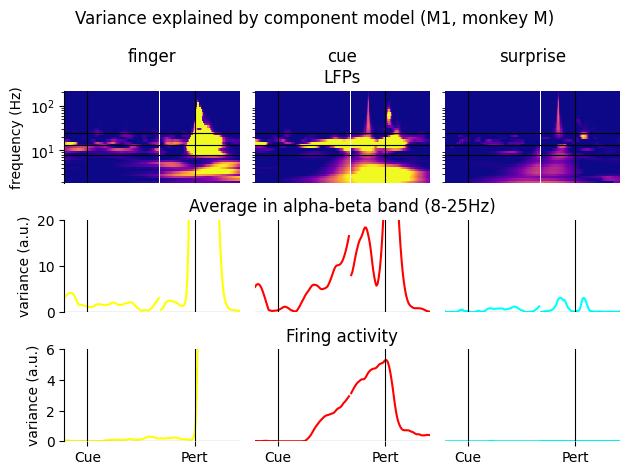

In [85]:
roi = 'M1'
epoch = 'exec'
rec = [25, 27, 28] #recordings[roi]
freq = freq_masks['alpha-beta']
var_expl_lfp, var_expl_spk = [], []
for r in rec:
    theta_lfp = np.load(os.path.join(path_lfp, f'theta_in.lfp.component.{monkey}.{roi}.{epoch}-{r}.npy'))
    theta_spk = np.load(os.path.join(path_spk, f'theta_in.spike.component.{monkey}.{roi}.aligned.{epoch}-{r}.npy'))
    var_expl_lfp.append(np.exp(theta_lfp))
    var_expl_spk.append(np.exp(theta_spk))
var_expl_lfp = np.array(var_expl_lfp)
var_expl_spk = np.array(var_expl_spk)

fig, axs = plt.subplots(3, 3, sharey='row', sharex=True)

vmin, vmax = 0, 12
color = ['#FFFF00', 'red', 'cyan']
label = ['finger', 'cue', 'surprise']
for i in range(3):
    axs[0, i].pcolormesh(t_cue, foi, var_expl_lfp[:, :, :cuePost, i].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, i].pcolormesh(t_pert, foi, var_expl_lfp[:, :, pertPre:, i].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, i].set_yscale('log')
    axs[0, i].axhline(8, color='k', lw='.8')
    axs[0, i].axhline(13, color='k', lw='.8')
    axs[0, i].axhline(24, color='k', lw='.8')
    axs[1, i].plot(t_cue, var_expl_lfp[:, freq, :cuePost, i].mean(axis=(0, 1)), color=color[i])
    axs[1, i].plot(t_pert, var_expl_lfp[:, freq, pertPre:, i].mean(axis=(0, 1)), color=color[i])
    axs[2, i].plot(t_cue, var_expl_spk[:, :cuePost, i].mean(axis=0), color=color[i])
    axs[2, i].plot(t_pert, var_expl_spk[:, pertPre:, i].mean(axis=0), color=color[i])
    axs[1, i].axhline(0, color='k', lw='.8')
    axs[2, i].axhline(0, color='k', lw='.8')
    axs[1, i].set_ylim(0, 20)
    axs[2, i].set_ylim(0, 6)
    for j in range(3):
        axs[j, i].axvline(cueIdx, color='k', lw='.8')
        axs[j, i].axvline(pertIdx, color='k', lw='.8')
        if j < 2:
            axs[j, i].tick_params(bottom=False, labelbottom=False)
        else:
            axs[j, i].set_xticks([cueIdx, pertIdx])
            axs[j, i].set_xticklabels(['Cue', 'Pert'])
        if i==0:
            axs[j, i].spines[['top', 'right', 'bottom']].set_visible(False)
        else:
            axs[j, i].spines[['top', 'right', 'bottom', 'left']].set_visible(False)
            axs[j, i].tick_params(left=False)

axs[0, 0].set_title('finger\n')
axs[0, 1].set_title('cue\nLFPs')
axs[0, 2].set_title('surprise\n')
axs[0, 0].set_ylabel('frequency (Hz)')
axs[1, 0].set_ylabel('variance (a.u.)')
axs[1, 1].set_title('Average in alpha-beta band (8-25Hz)')
axs[2, 0].set_ylabel('variance (a.u.)')
axs[2, 1].set_title('Firing activity')

fig.suptitle(f'Variance explained by component model ({roi}, monkey {monkey[0]})')
fig.tight_layout()

plt.show()

In [ ]:
roi = 'M1'
rec = 25
lfp = np.load(path_lfp + f'/lfp_aligned.{roi}-{rec}.npy')
freq = freq_masks['beta']
lfp = lfp[:, :, freq].mean(axis=2)

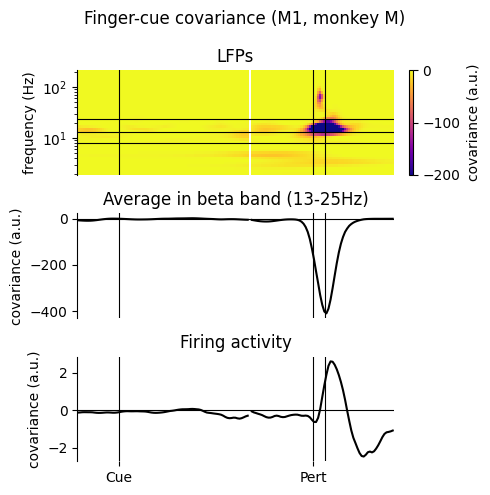

In [148]:
roi = 'S1'
epoch = 'exec'
rec = [25, 27, 28] #recordings[roi]
freq = freq_masks['beta']
corr_lfp, corr_spk = [], []
for r in rec:
    theta = np.load(os.path.join(path_lfp, f'theta_in.lfp.feature.{monkey}.{roi}.{epoch}-{r}.npy'))
    theta2 = theta ** 2
    covariance = theta[..., 1] * theta[..., 2]
    stds = np.sqrt((theta2[..., 0] + theta2[..., 1]) * theta2[..., 2])
    correlation = covariance / stds
    corr_lfp.append(covariance)
    theta = np.load(os.path.join(path_spk, f'theta_in.spike.feature.{monkey}.{roi}.aligned.{epoch}-{r}.npy'))
    theta2 = theta ** 2
    covariance = theta[..., 1] * theta[..., 2]
    stds = np.sqrt((theta2[..., 0] + theta2[..., 1]) * theta2[..., 2])
    correlation = covariance / stds
    corr_spk.append(covariance)
corr_lfp = np.array(corr_lfp)
corr_spk = np.array(corr_spk)

fig, axs_ = plt.subplots(3, 2, sharex='col', figsize=(5, 5), gridspec_kw={"width_ratios": [80, 1]})

axs = axs_[:, 0]
ax_c = axs_[:, 1]

vmin, vmax = -200, 0
color = 'k'
h = axs[0].pcolormesh(t_cue, foi, corr_lfp[:, :, :cuePost].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
axs[0].pcolormesh(t_pert, foi, corr_lfp[:, :, pertPre:].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
axs[0].set_yscale('log')
axs[0].axhline(8, color='k', lw='.8')
axs[0].axhline(13, color='k', lw='.8')
axs[0].axhline(24, color='k', lw='.8')
axs[1].plot(t_cue, corr_lfp[:, freq, :cuePost].mean(axis=(0, 1)), color=color)
axs[1].plot(t_pert, corr_lfp[:, freq, pertPre:].mean(axis=(0, 1)), color=color)
axs[2].plot(t_cue, corr_spk[:, :cuePost].mean(axis=0), color=color)
axs[2].plot(t_pert, corr_spk[:, pertPre:].mean(axis=0), color=color)
axs[1].axhline(0, color='k', lw='.8')
axs[2].axhline(0, color='k', lw='.8')
for j in range(3):
    axs[j].axvline(cueIdx, color='k', lw='.8')
    axs[j].axvline(pertIdx, color='k', lw='.8')
    axs[j].axvline(pertIdx + 6, color='k', lw='.8')
    if j < 2:
        axs[j].tick_params(bottom=False, labelbottom=False)
    else:
        axs[j].set_xticks([cueIdx, pertIdx])
        axs[j].set_xticklabels(['Cue', 'Pert'])
    axs[j].spines[['top', 'right', 'bottom']].set_visible(False)

axs[0].set_title('LFPs')
axs[0].set_ylabel('frequency (Hz)')
axs[1].set_ylabel('covariance (a.u.)')
axs[1].set_title('Average in beta band (13-25Hz)')
axs[2].set_ylabel('covariance (a.u.)')
axs[2].set_title('Firing activity')

fig.colorbar(h, cax=ax_c[0], label='covariance (a.u.)')
for ax in ax_c[1:]:
    ax.remove()

fig.suptitle(f'Finger-cue covariance ({roi}, monkey {monkey[0]})')
fig.tight_layout()

plt.show()

In [13]:
roi = 'S1'
epoch = 'plan'
rec = [26, 27, 28]#recordings[roi]
freq = freq_masks['alpha-beta']
var_expl_lfp, var_expl_spk = [], []
for r in rec:
    theta_lfp = np.load(os.path.join(path_lfp, monkey, f'theta_in.lfp.{monkey}.{roi}.{epoch}-{r}.npy'))
    theta_spk = np.load(os.path.join(path_spk, monkey, f'theta_in.spike.component.{monkey}.{roi}.aligned.{epoch}-{r}.npy'))
    var_expl_lfp.append(np.exp(theta_lfp))
    var_expl_spk.append(np.exp(theta_spk))
var_expl_lfp = np.array(var_expl_lfp)
var_expl_spk = np.array(var_expl_spk)

fig, axs = plt.subplots(3, 2, sharey='row', sharex=True)

vmin, vmax = 0, 12
color = ['red', 'blue']
label = ['cue', 'uncertainty']
for i in range(2):
    axs[0, i].pcolormesh(t_cue, foi, var_expl_lfp[:, :, :cuePost, i].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, i].pcolormesh(t_pert, foi, var_expl_lfp[:, :, pertPre:, i].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, i].set_yscale('log')
    axs[0, i].axhline(8, color='k', lw='.8')
    axs[0, i].axhline(13, color='k', lw='.8')
    axs[0, i].axhline(24, color='k', lw='.8')
    axs[1, i].plot(t_cue, var_expl_lfp[:, freq, :cuePost, i].mean(axis=(0, 1)), color=color[i])
    axs[1, i].plot(t_pert, var_expl_lfp[:, freq, pertPre:, i].mean(axis=(0, 1)), color=color[i])
    axs[2, i].plot(t_cue, var_expl_spk[:, :cuePost, i].mean(axis=0), color=color[i])
    axs[2, i].plot(t_pert, var_expl_spk[:, pertPre:, i].mean(axis=0), color=color[i])
    axs[1, i].axhline(0, color='k', lw='.8')
    axs[2, i].axhline(0, color='k', lw='.8')
    # axs[1, i].set_ylim(0, 20)
    # axs[2, i].set_ylim(0, .5)
    for j in range(3):
        axs[j, i].axvline(cueIdx, color='k', lw='.8')
        axs[j, i].axvline(pertIdx, color='k', lw='.8')
        if j < 2:
            axs[j, i].tick_params(bottom=False, labelbottom=False)
        else:
            axs[j, i].set_xticks([cueIdx, pertIdx])
            axs[j, i].set_xticklabels(['Cue', 'Pert'])
        if i==0:
            axs[j, i].spines[['top', 'right', 'bottom']].set_visible(False)
        else:
            axs[j, i].spines[['top', 'right', 'bottom', 'left']].set_visible(False)
            axs[j, i].tick_params(left=False)

axs[0, 0].set_title('cue\nLFPs')
axs[0, 1].set_title('uncertainty\nLFPs')
axs[0, 0].set_ylabel('frequency (Hz)')
axs[1, 0].set_ylabel('variance (a.u.)')
axs[1, 0].set_title('Average in alpha-beta band (8-25Hz)')
axs[2, 0].set_ylabel('variance (a.u.)')
axs[2, 0].set_title('Firing activity')

fig.suptitle(f'Variance explained by component model ({roi}, monkey {monkey[0]})')
fig.tight_layout()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/cifs/pruszynski/Marco/SensoriMotorPrediction/LFPs/Pert/theta_in.lfp.Pert.S1.plan-26.npy'

In [38]:
roi = 'PMd'
rec = recordings[roi]

lfp = np.load(os.path.join(path, f'lfp_aligned-{rec}.npy'))
lfp_avg = lfp.mean(axis=(1, 3)).T

fig, ax = plt.subplots()
ax.axvline(cueIdx, color='k')
ax.axvline(pertIdx, color='k')
ax.axhline(8, color='k')
ax.axhline(13, color='k')
ax.axhline(24, color='k')

ax.pcolormesh(t, foi, lfp_avg)
ax.set_yscale('log')


NameError: name 'recordings' is not defined

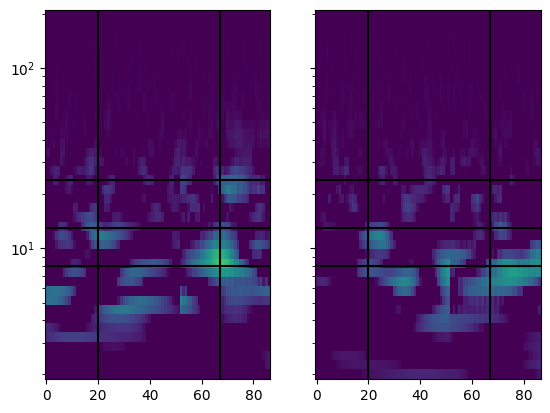

In [46]:
roi = 'PMd'
epoch = 'plan'
rec = recordings[roi]
theta = np.load(os.path.join(path, f'theta_in.lfp.{monkey}.{roi}.{epoch}-{rec}.npy'))
var_expl = np.sqrt(np.exp(theta))

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True)

vmin, vmax = 0, 5

for i, ax in enumerate(axs):
    ax.pcolormesh(t, foi, var_expl[..., i], vmin=vmin, vmax=vmax)
    ax.set_yscale('log')
    ax.axvline(cueIdx, color='k')
    ax.axvline(pertIdx, color='k')
    ax.axhline(8, color='k')
    ax.axhline(13, color='k')
    ax.axhline(24, color='k')
    # ax.set_xlim(0, cuePost)

plt.show()

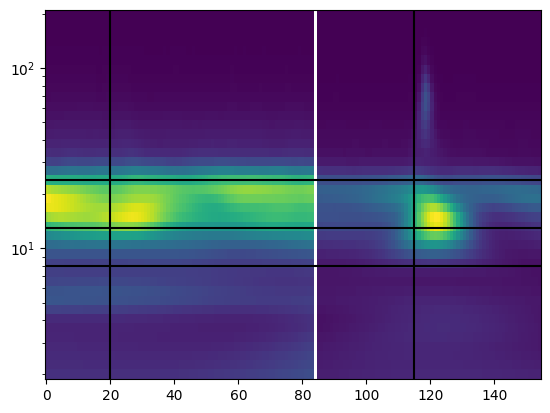

In [50]:
roi = 'PMd'
rec = 19

lfp = np.load(os.path.join(path_lfp, f'lfp_aligned.{roi}-{rec}.npy'))
lfp_avg = lfp.mean(axis=(1, 3)).T

fig, ax = plt.subplots()
ax.axvline(cueIdx, color='k')
ax.axvline(pertIdx, color='k')
ax.axhline(8, color='k')
ax.axhline(13, color='k')
ax.axhline(24, color='k')

ax.pcolormesh(t_cue, foi, lfp_avg[:, :cuePost])
ax.pcolormesh(t_pert, foi, lfp_avg[:, pertPre:])
ax.set_yscale('log')
